In [13]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [14]:
file_path = 'Results.json'

with open(file_path, 'r', encoding='utf-8') as f:
    json_data = json.load(f)

# 2. חילוץ הנתונים למבנה שטוח (Flattening)
records = []
for file_key, content in json_data.items():
    language = content.get("metadata", {}).get("language", "unknown")
    
    # מעבר על כל מודל LLM בתוך כל קטע קוד
    for model_name, metrics in content.items():
        if model_name != "metadata" and isinstance(metrics, dict):
            records.append({
                "file_key": file_key,
                "language": language,
                "model": model_name,
                "readability_score": metrics.get("readability_score"),
                "maintainability_score": metrics.get("maintainability_score")
            })

In [15]:
df = pd.DataFrame(records)

In [16]:
avg_readability = df.groupby("model")["readability_score"].mean().reset_index()

print("ממוצע ציון הקריאות לפי מודל:")
print(avg_readability)

ממוצע ציון הקריאות לפי מודל:
           model  readability_score
0        ChatGPT          85.703333
1         Claude          74.070000
2         Gemini          80.166667
3  GithubCopilot          77.996667
4      Sonarqube          86.266667


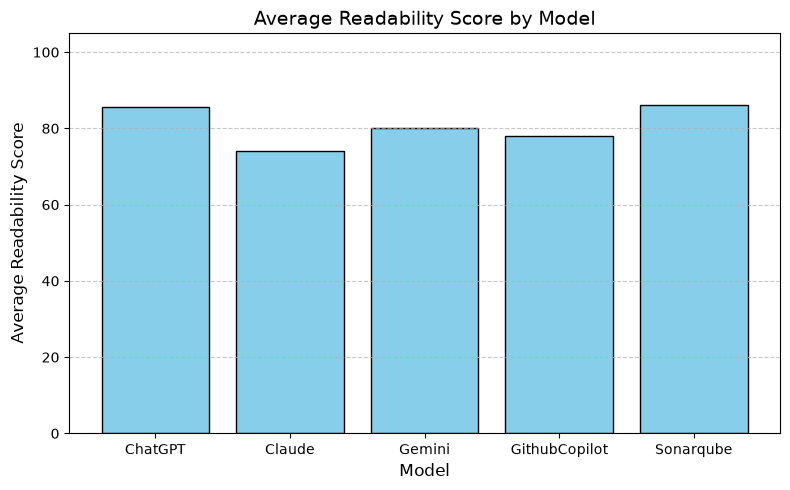

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(avg_readability["model"], avg_readability["readability_score"], color='skyblue', edgecolor='black')

plt.title("Average Readability Score by Model", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Average Readability Score", fontsize=12)
plt.ylim(0, 105)  # סקאלה מ-0 עד 100
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()